In [2]:
import sys
sys.path.append("../")

from models.bulge_models import BulgeTemplates
from models.templates import LorimerDiskTemplate
from models.np_model import NPModel

%load_ext autoreload
%autoreload 2

In [3]:
import jax
import jax.numpy as jnp
import numpyro.distributions as dist

In [4]:
import healpy as hp
import matplotlib.pyplot as plt

In [5]:
r_outer = 25
l_max = 0

vary_disk = True
vary_gamma = True
bulge_hybrid = True

dif = "ModelO"
ps_cat = "3fgl"
nside = 128

npmodel = NPModel(dif=dif, r_outer=r_outer, l_max=l_max, vary_disk=vary_disk, vary_gamma=vary_gamma, bulge_hybrid=bulge_hybrid, ps_cat=ps_cat, nside=nside)
svi_results = npmodel.fit_svi(rng_key=jax.random.PRNGKey(4234), n_steps=5000)


Loading the psf correction from: /net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


100%|██████████| 5000/5000 [05:22<00:00, 15.52it/s, init loss: 23282.3701, avg. loss [4751-5000]: 20097.5984]


In [94]:
import arviz as az

posterior = npmodel.get_posterior_samples(rng_key=jax.random.PRNGKey(42342), num_samples=50000)

In [95]:
posterior_bulge = {}
for key in list(posterior.keys()):
    if "theta" in key:
        posterior_bulge[key] = posterior[key]
        posterior.pop(key, None)

In [96]:
az.summary(posterior)

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
C,2.924,0.951,1.283,4.709,0.004,0.003,50243.0,50054.0,NaN
S_bub,1.149,0.111,0.946,1.363,0.001,0.000,49450.0,48164.0,NaN
S_dif,11.284,0.178,10.958,11.624,0.001,0.001,49962.0,49734.0,NaN
S_gce,0.872,0.278,0.352,1.373,0.001,0.001,49832.0,48168.0,NaN
S_ics,4.765,0.311,4.248,4.999,0.001,0.001,50110.0,50172.0,NaN
S_iso,0.986,0.260,0.531,1.481,0.001,0.001,49623.0,49678.0,NaN
S_psc,2.350,1.396,0.125,4.627,0.006,0.004,49464.0,49049.0,NaN
Sps_dsk,1.698,0.221,1.282,1.982,0.001,0.001,50005.0,50091.0,NaN
Sps_gce,0.625,0.217,0.246,1.031,0.001,0.001,49910.0,49511.0,NaN
f_bulge_poiss,0.418,0.263,0.014,0.871,0.001,0.001,49635.0,49913.0,NaN


In [97]:
jnp.mean(posterior_bulge['theta_bulge_poiss'], 0)

DeviceArray([0.05926641, 0.05665744, 0.11834171, 0.36133431, 0.40440013],            dtype=float64)

In [98]:
jnp.mean(posterior_bulge['theta_bulge_ps'], 0)

DeviceArray([0.10131167, 0.09122446, 0.13864721, 0.33303835, 0.33577832],            dtype=float64)

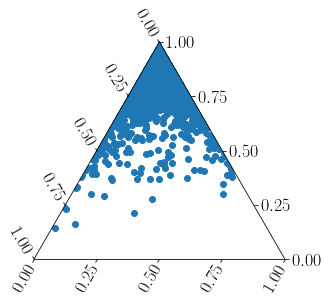

In [99]:
import mpltern

ax = plt.subplot(projection='ternary')
ax.scatter(*posterior_bulge['theta_ics'].T)     

In [107]:
posterior_ics = {}
for i in range(3):
    posterior_ics[str(i)] = posterior_bulge['theta_ics'][:, i]
az.summary(az.from_dict(posterior_ics))

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,0.971,0.054,0.895,1.000,0.0,0.0,49880.0,48968.0,NaN
1,0.017,0.041,0.000,0.067,0.0,0.0,49815.0,49601.0,NaN
2,0.012,0.031,0.000,0.047,0.0,0.0,49255.0,49874.0,NaN


In [108]:
posterior_ics = {}
for i in range(3):
    posterior_ics[str(i)] = posterior_bulge['theta_pibrem'][:, i]
az.summary(az.from_dict(posterior_ics))

Shape validation failed: input_shape: (1, 50000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,0.807,0.060,0.692,0.911,0.0,0.0,50859.0,50046.0,NaN
1,0.131,0.070,0.000,0.244,0.0,0.0,50129.0,49395.0,NaN
2,0.062,0.069,0.000,0.196,0.0,0.0,50824.0,50513.0,NaN
